<a href="https://colab.research.google.com/github/Ma-rCh/ML-Basic/blob/main/homework_10/homework_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [137]:
#YOUR CODE HERE
#1. Загрузка  данных
import kagglehub
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from scipy import stats
from scipy.stats import norm

path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")
dc = pd.read_csv(f'{path}/AB_NYC_2019.csv')
print(f"\\nРазмер: {dc.shape}")
df = dc.copy()
print(dc.isnull().sum())
#dc.head()


Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
\nРазмер: (48895, 16)
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [138]:
#2. Очистка данных
#выкинем ненужные признаки: id, name, host_id, host_name, last_review
df_clean = df.drop(['id','name','host_id','host_name','last_review'], axis=1)
#заполняем 0 пропущенные reviews_per_month
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)
#пропусков нет теперь
#помимо выбросов, в этих графиках есть еще одна аномалия
data = df_clean.copy()
data = data[data['price'] > 0]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48884 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48884 non-null  object 
 1   neighbourhood                   48884 non-null  object 
 2   latitude                        48884 non-null  float64
 3   longitude                       48884 non-null  float64
 4   room_type                       48884 non-null  object 
 5   price                           48884 non-null  int64  
 6   minimum_nights                  48884 non-null  int64  
 7   number_of_reviews               48884 non-null  int64  
 8   reviews_per_month               48884 non-null  float64
 9   calculated_host_listings_count  48884 non-null  int64  
 10  availability_365                48884 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 4.5+ MB


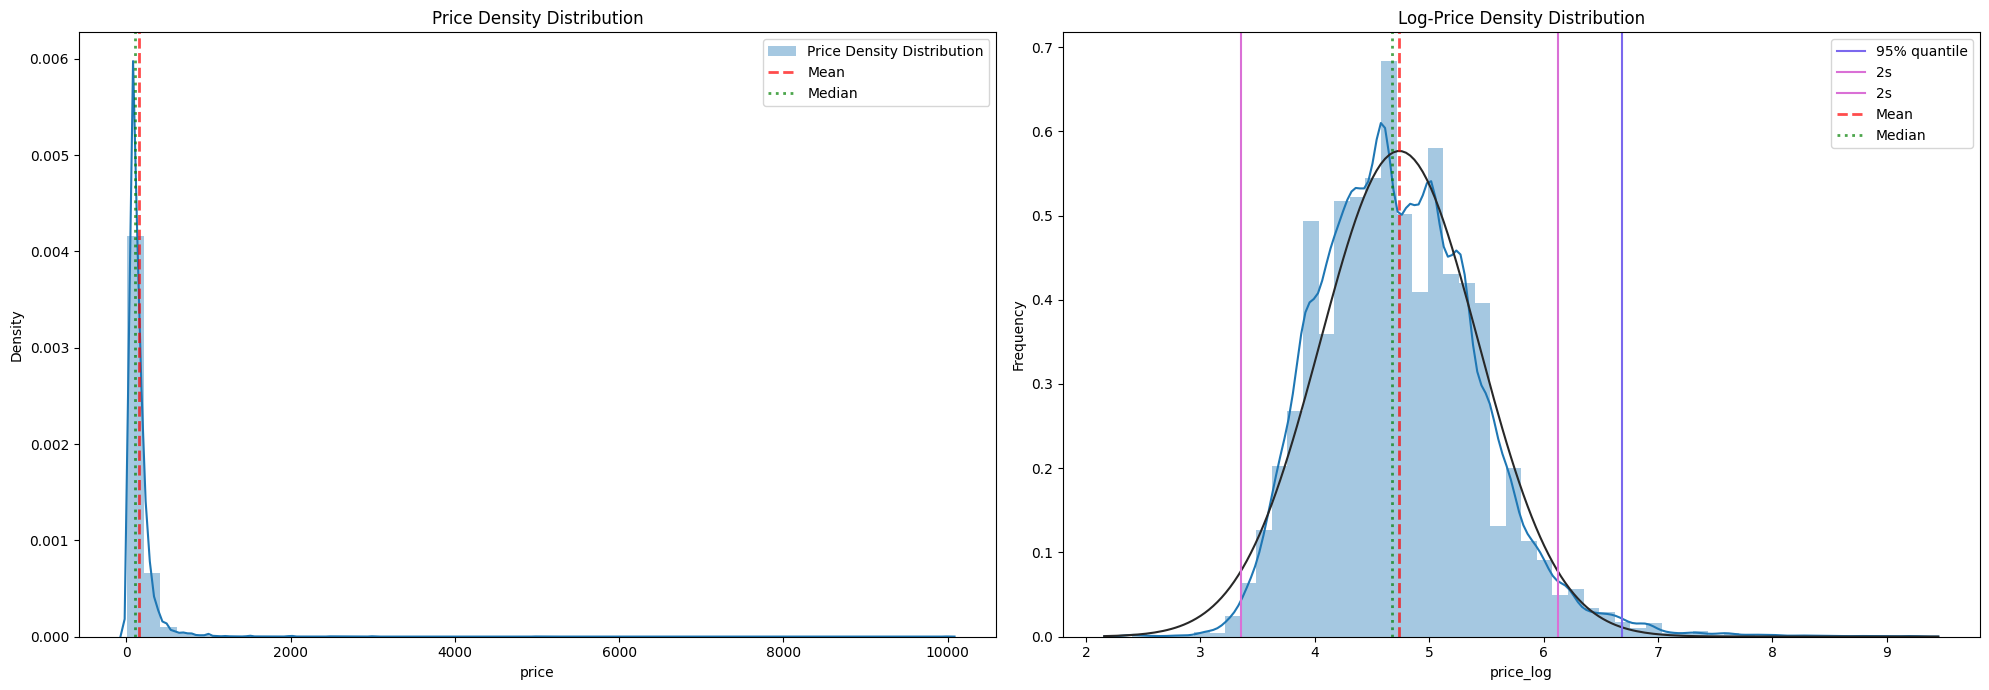


 Normal dist. mu= 4.74 andsigma=$ 0.69 


<Figure size 640x480 with 0 Axes>

In [139]:
#3. распределение целевой переменной
import warnings
warnings.filterwarnings('ignore')
import numpy as np
from scipy.stats import norm

# Создаём логарифмированную переменную
data['price_log'] = np.log1p(data['price'])

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.distplot(data['price'], ax=axes[0], label='Price Density Distribution')
axes[0].axvline(np.mean(data.price), color='red', linestyle='--', linewidth=2, alpha=0.7, label='Mean')
axes[0].axvline(data.price.median(), color='green', linestyle=':', linewidth=2, alpha=0.7, label='Median')
axes[0].set_title('Price Density Distribution')
axes[0].legend()

(mu, sigma) = norm.fit(data['price_log'])

lower_bound =mu - 2 * sigma
upper_bound =mu + 2 * sigma

sns.distplot(data['price_log'], fit=norm, ax=axes[1])
axes[1].axvline(data.price_log.quantile(0.99), label='95% quantile', c='mediumslateblue')
axes[1].axvline( lower_bound, label='2s', c='orchid')
axes[1].axvline( upper_bound, label='2s', c='orchid')
axes[1].axvline(np.mean(data.price_log), color='red', linestyle='--', linewidth=2, alpha=0.7, label='Mean')
axes[1].axvline(data.price_log.median(), color='green', linestyle=':', linewidth=2, alpha=0.7, label='Median')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log-Price Density Distribution')
#axes[1].legend(['Normal dist. ($\\mu=$ {:.2f} and $\\sigma=$ {:.2f} )'.format(mu, sigma)], loc='best')
axes[1].legend()
plt.tight_layout()
plt.show()

plt.tight_layout()
print(f"\n Normal dist. mu= {mu:.2f} andsigma=$ {sigma:.2f} ")

#нормальное распределение, после разделения на train/test можно почистить выбросы -поэтому там код не закооментирован

# Но по просьбе трудящихся удаляем выбросы здесь - так точность увеличиться на 5%
data = data[
    (data['price_log'] >= lower_bound) &
    (data['price_log'] <= upper_bound)
].copy()


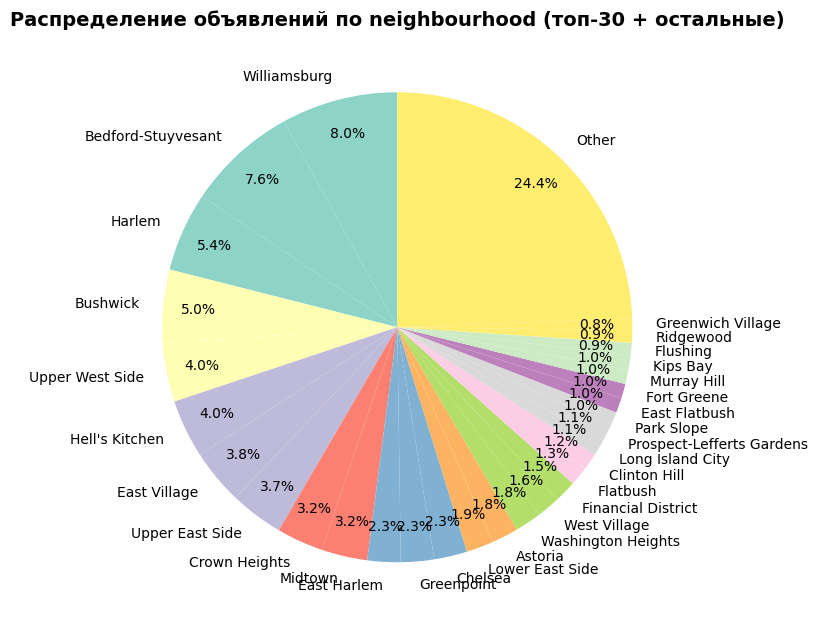

In [140]:
#4. посмотрим что за переменная neighbourhood
neighbourhood_counts = df['neighbourhood'].value_counts()
top_10 = neighbourhood_counts.head(30)
other_count = neighbourhood_counts[30:].sum()

pie_data = pd.concat([top_10, pd.Series({'Other': other_count})])

plt.figure(figsize=(8, 8))
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))
wedges, texts, autotexts = plt.pie(pie_data.values, labels=pie_data.index,
                                     autopct='%1.1f%%', colors=colors_pie,
                                     startangle=90, pctdistance=0.85)
plt.title('Распределение объявлений по neighbourhood (топ-30 + остальные)',
          fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


In [141]:
#5. feature ingineering
# One-Hot Encoding для категориальных признаков (кроме neighbourhood)
data['room_type_enc'] = data['room_type'].map({'Private room':2, 'Entire home/apt':3, 'Shared room':1})
data = pd.get_dummies(data, columns=['neighbourhood_group', 'room_type'],
                            prefix=['ng', 'rt'], drop_first=True,dtype=int)
# neighbourhood - по медиане
neighborough_medians = np.log1p(data.groupby('neighbourhood')['price'].median())
data['bourough_enc'] = data['neighbourhood'].map(neighborough_medians)
#  Простая обработка пиков цен (кратно 100, равно 50 ...)
data['rounded_100'] = (data['price'] % 100 == 0).astype(int)#|(data['price'] % 100>=99).astype(int)
data['rounded_50'] = (data['price'] % 50 == 0).astype(int)#|(data['price'] % 50 >=49 ).astype(int)
data['eq_50'] = (data['price'] == 50).astype(int)
data['eq_100'] = (data['price'] == 100).astype(int)
#data['res_50'] =
#data['res_100'] =
data.head()

,neighbourhood,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price_log,...,ng_Manhattan,ng_Queens,ng_Staten Island,rt_Private room,rt_Shared room,bourough_enc,rounded_100,rounded_50,eq_50,eq_100
0,Kensington,40.64749,-73.97237,149,1,9,0.21,6,365,5.010635,...,0,0,0,1,0,4.262680,0,0,0,0
1,Midtown,40.75362,-73.98377,225,1,45,0.38,2,355,5.420535,...,1,0,0,0,0,5.278115,0,0,0,0
2,Harlem,40.80902,-73.94190,150,3,0,0.00,1,365,5.017280,...,1,0,0,1,0,4.499810,0,1,0,0
3,Clinton Hill,40.68514,-73.95976,89,1,270,4.64,1,194,4.499810,...,0,0,0,0,0,4.787492,0,0,0,0
4,East Harlem,40.79851,-73.94399,80,10,9,0.10,1,0,4.394449,...,1,0,0,0,0,4.605170,0,0,0,0


In [142]:
# расстояние до цента Манхеттена(взять евк или хвс расстояние и округлить)

from math import radians, sin, cos, sqrt, atan2
#  Геометрический центр'Midtown Manhattan'
CENTER_LAT, CENTER_LON = 40.7549, -73.9840

def haversine_distance(lat1, lon1, lat2, lon2):
       R = 6371
       lat1_rad, lat2_rad = radians(lat1), radians(lat2)
       dlat = radians(lat2 - lat1)
       dlon = radians(lon2 - lon1)
       a = sin(dlat/2)**2 + cos(lat1_rad)*cos(lat2_rad)*sin(dlon/2)**2
       return R * 2 * atan2(sqrt(a), sqrt(1-a))

def euclidean_distance(lat1, lon1, lat2, lon2):
    """
    Приближенное евклидово расстояние (в километрах)
    Быстрее, но менее точно на больших расстояниях
    """
    # 1 градус широты ≈ 111.32 км
    # 1 градус долготы ≈ 111.32 * cos(широта) км
    lat_km = 111.32
    lon_km = 111.32 * cos(radians((lat1 + lat2) / 2))

    dlat_km = (lat2 - lat1) * lat_km
    dlon_km = (lon2 - lon1) * lon_km

    return sqrt(dlat_km**2 + dlon_km**2)
#df0 = data.copy()
data['D_to_manhattan_km'] = data.apply(
       lambda row:    euclidean_distance(row['latitude'], row['longitude'],
                                      CENTER_LAT, CENTER_LON), axis=1
   ).round(2)
#data.head()


In [143]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
print(numeric_cols)

['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'price_log', 'room_type_enc', 'ng_Brooklyn', 'ng_Manhattan', 'ng_Queens', 'ng_Staten Island', 'rt_Private room', 'rt_Shared room', 'bourough_enc', 'rounded_100', 'rounded_50', 'eq_50', 'eq_100', 'D_to_manhattan_km']


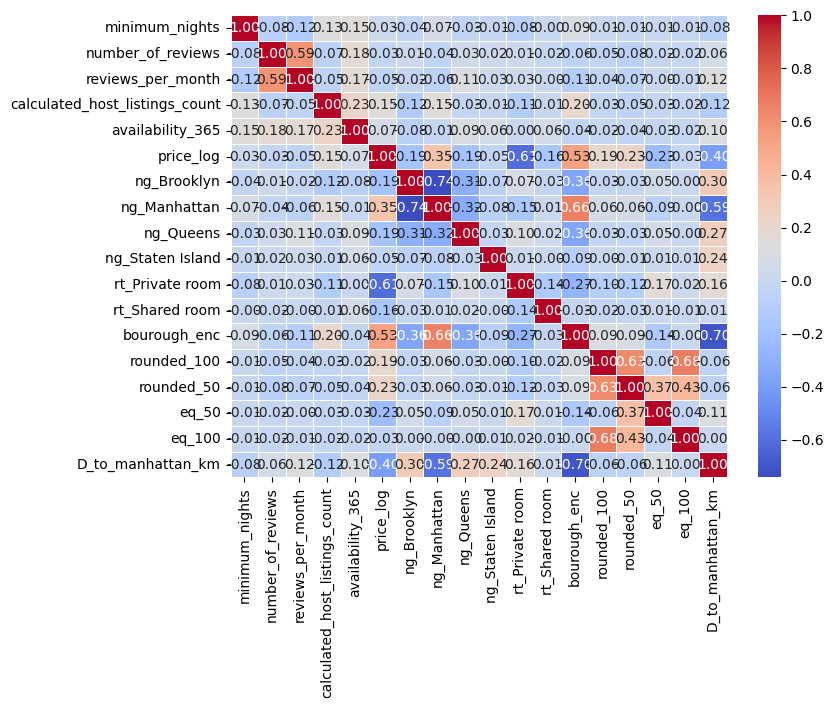

In [144]:
#correlation map
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

# Обычно исключаем:
exclude_for_model = [ 'latitude', 'longitude',
                     'price',
                      'room_type_enc']

# Числовые колонки, которые МОЖНО использовать
model_cols = [c for c in numeric_cols if c not in exclude_for_model]
correlation_matrix = data[model_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(data[model_cols].corr(), cmap='coolwarm', annot=True, cbar=True, linewidths=.5, fmt= '.2f')
plt.show()

  Найдено 4 пар с |r| > 0.35



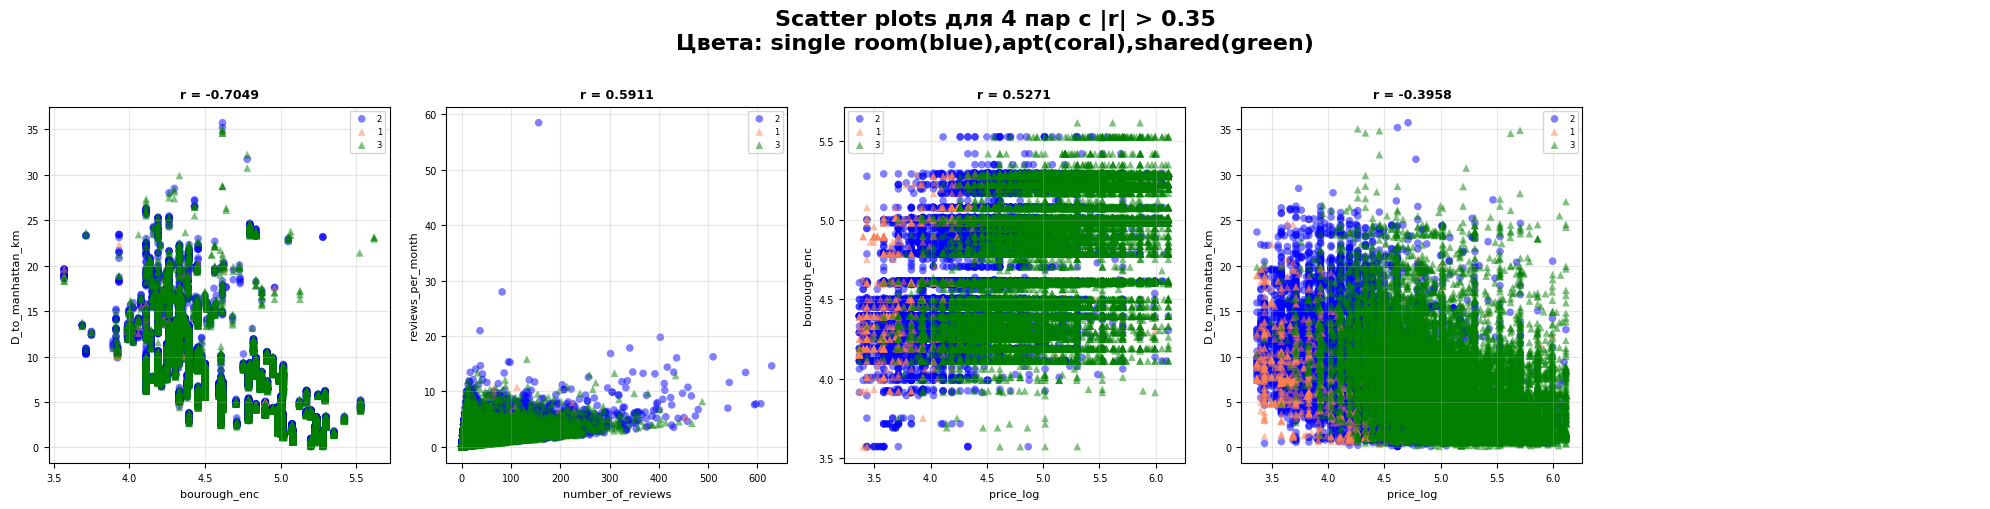

In [145]:
#pairplots
exclude_for_model2 = [ 'latitude', 'longitude', 'price','ng_Brooklyn', 'ng_Manhattan', 'ng_Queens', 'ng_Staten Island', 'rt_Private room',
                      'rt_Shared room','room_type_enc','rounded_100', 'eq_50', 'eq_100','rounded_50' ]

# Числовые колонки, которые МОЖНО использовать
model_cols2 = [c for c in numeric_cols if c not in exclude_for_model2]
correlation_matrix = data[model_cols2].corr()


high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.35:
            high_corr_pairs.append({
                'feature1': correlation_matrix.columns[i],
                'feature2': correlation_matrix.columns[j],
                'correlation': corr_val
            })

# Сортируем по убыванию |r|
high_corr_pairs_sorted = sorted(high_corr_pairs,
                                key=lambda x: abs(x['correlation']),
                                reverse=True)

print(f"  Найдено {len(high_corr_pairs_sorted)} пар с |r| > 0.35\n")
#print((high_corr_pairs_sorted))
n_pairs = len(high_corr_pairs_sorted)
n_cols = 5
n_rows = (n_pairs + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for idx, pair in enumerate(high_corr_pairs_sorted):
    ax = axes[idx]
    f1, f2, corr = pair['feature1'], pair['feature2'], pair['correlation']

    # Scatter plot с раскраской по диагнозу
    for room_type_enc, color, marker, alpha in [
        (2, 'blue', 'o', 0.5),
        (1, 'coral', '^', 0.5),
        (3, 'green', '^', 0.5)
    ]:
        mask = data['room_type_enc'] == room_type_enc
        ax.scatter(data.loc[mask, f1], data.loc[mask, f2],
                  c=color, marker=marker, alpha=alpha, s=30,
                  edgecolors='none', label=room_type_enc)



    ax.set_xlabel(f1, fontsize=8)
    ax.set_ylabel(f2, fontsize=8)
    ax.set_title(f'r = {corr:.4f}', fontsize=9, fontweight='bold')
    ax.legend(fontsize=6, loc='best')
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=7)
    plt.suptitle(f'Scatter plots для {n_pairs} пар с |r| > 0.35\nЦвета: single room(blue),apt(coral),shared(green)',
                fontsize=16, fontweight='bold', y=1.01)

for idx in range(n_pairs, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats
from math import radians, sin, cos, sqrt, atan2
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')


# Разделяем ДО удаления выбросов
data_train, data_test = train_test_split(data, test_size=0.3, random_state=42)

# Считаем выбросы до
outliers_train_before = (
    (data_train['price_log'] < lower_bound) |
    (data_train['price_log'] > upper_bound)
).sum()

# Удаляем выбросы
data_train_clean = data_train[
    (data_train['price_log'] >= lower_bound) &
    (data_train['price_log'] <= upper_bound)
].copy()

outliers_train_removed = len(data_train) - len(data_train_clean)

print(f"  Выбросов на train: {outliers_train_before} ({outliers_train_before/len(data_train)*100:.1f}%)")
print(f"  Удалено: {outliers_train_removed}")
print(f"  Train после очистки: {len(data_train_clean)}")

X_train = data_train_clean[model_cols].drop(['price_log'],axis = 1)
X_test = data_test[model_cols].drop(['price_log'],axis = 1)
y_train = data_train_clean['price_log']
y_test = data_test['price_log']

print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")

#X_train.head()

  Выбросов на train: 0 (0.0%)
  Удалено: 0
  Train после очистки: 33024
  X_train: (33024, 17)
  X_test:  (14154, 17)


In [147]:
try:
    import xgboost as xgb
    from xgboost import XGBRegressor
    print("✅ XGBoost уже установлен")
except ImportError:
    print("📦 Устанавливаю XGBoost...")
    !pip install xgboost -q
    import xgboost as xgb
    from xgboost import XGBRegressor
    print("✅ XGBoost установлен")

✅ XGBoost уже установлен



 ОПРЕДЕЛЕНИЕ МОДЕЛЕЙ
----------------------------------------
  ✅ Linear Regression готов
  ✅ RidgeCV готов
  ✅ LassoCV готов
  ✅ ElasticNetCV готов
  ✅ XGBoost  готов

🤖 6. ОБУЧЕНИЕ МОДЕЛЕЙ
----------------------------------------

  Linear Regression
    R² (log): 0.6392
    RMSE ($): $57.85
    MAE ($):  $37.39
    MAPE:     28.8%
    CV R²:    0.6387 ± 0.0056
    Параметры: N/A

  RidgeCV
    R² (log): 0.6391
    RMSE ($): $57.85
    MAE ($):  $37.38
    MAPE:     28.8%
    CV R²:    0.6387 ± 0.0056
    Параметры: α=51.794747
    Признаков: 17

  LassoCV
    R² (log): 0.6392
    RMSE ($): $57.85
    MAE ($):  $37.38
    MAPE:     28.8%
    CV R²:    0.6387 ± 0.0056
    Параметры: α=0.000100
    Признаков: 17

  ElasticNetCV
    R² (log): 0.6392
    RMSE ($): $57.85
    MAE ($):  $37.38
    MAPE:     28.8%
    CV R²:    0.6387 ± 0.0056
    Параметры: α=0.000100, l1=0.10
    Признаков: 17

  XGBoost 
    R² (log): 0.7143
    RMSE ($): $52.29
    MAE ($):  $33.11
    MAPE:     25.0%


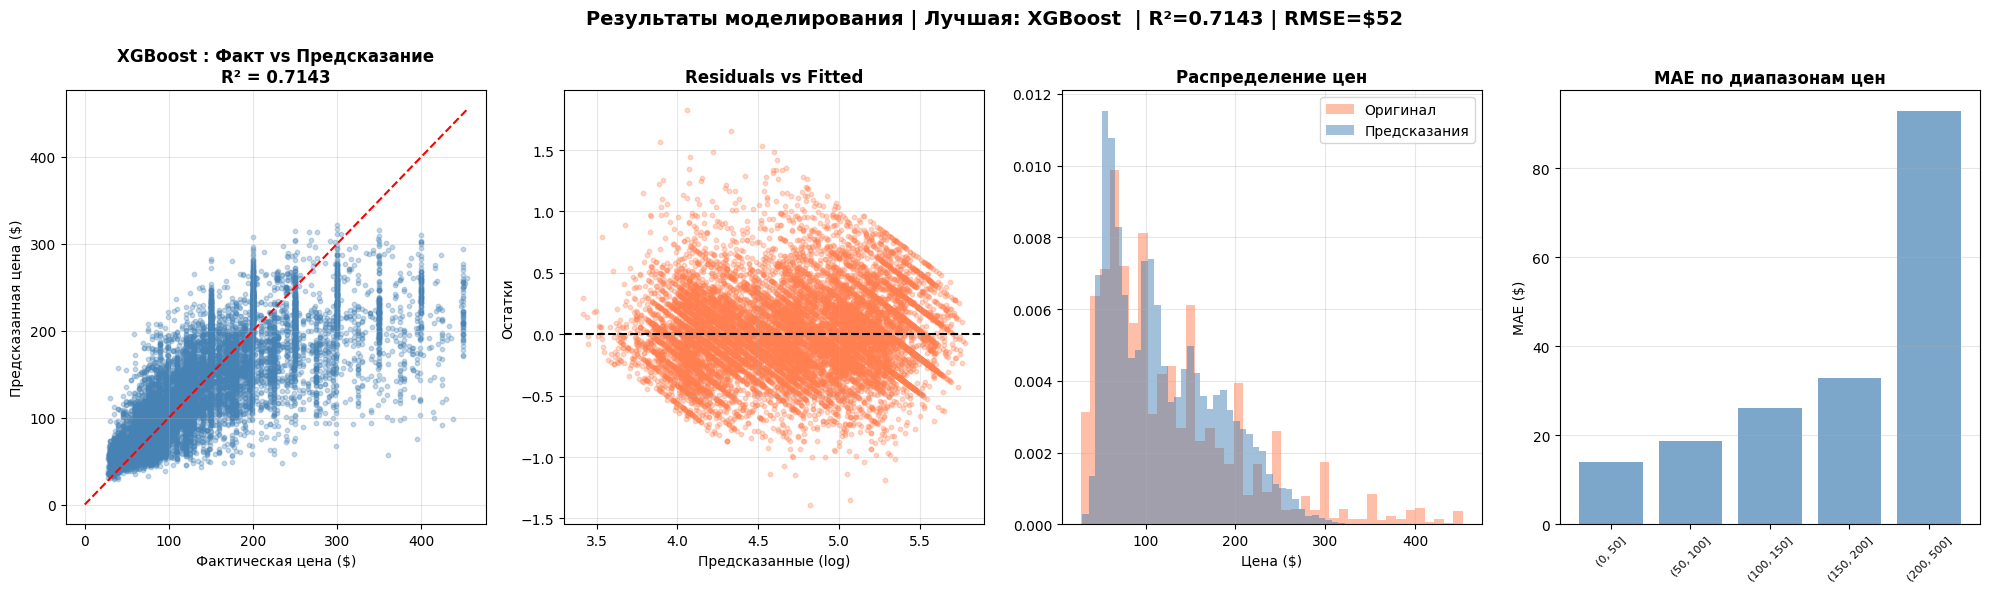


🔮 ПРИМЕРЫ ПРЕДСКАЗАНИЙ
----------------------------------------

      Факт   Предск   Ошибка   Ошибка %
  ----------------------------------------
  $  60.00 $  63.51 $  -3.51      -5.8%
  $ 220.00 $ 203.10 $ +16.90      +7.7%
  $ 232.00 $ 179.16 $ +52.84     +22.8%
  $  99.00 $  86.71 $ +12.29     +12.4%
  $  80.00 $  70.09 $  +9.91     +12.4%
  $  92.00 $ 116.77 $ -24.77     -26.9%
  $ 225.00 $ 139.85 $ +85.15     +37.8%
  $ 250.00 $ 216.05 $ +33.95     +13.6%
  $  38.00 $  54.74 $ -16.74     -44.0%
  $  35.00 $  57.20 $ -22.20     -63.4%

🏆 ИТОГИ МОДЕЛИРОВАНИЯ

✅ МОДЕЛИРОВАНИЕ ЗАВЕРШЕНО!

🏆 ЛУЧШАЯ МОДЕЛЬ: XGBoost 
   • R² (log): 0.7143
   • RMSE: $52.29
   • MAE: $33.11
   • MAPE: 25.0%
   • CV R²: 0.7111 ± 0.0047
   • Параметры: α=0.000100, l1=0.10
   • Признаков: 17


💡 ИНТЕРПРЕТАЦИЯ:
   • Модель объясняет 71.4% вариации log-цены
   • Средняя ошибка: ±$33
   • Ошибка в процентах: 25.0%

🚀 ИСПОЛЬЗОВАНИЕ:
   best_pipeline = results['XGBoost ']['pipeline']
   y_pred_log = best_pipe

In [148]:
print("\n ОПРЕДЕЛЕНИЕ МОДЕЛЕЙ")
print("-" * 40)

alphas = np.logspace(-4, 3, 50)

models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'RidgeCV': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RidgeCV(alphas=alphas, cv=5, scoring='r2'))
    ]),
    'LassoCV': Pipeline([
        ('scaler', RobustScaler()),
        ('model', LassoCV(alphas=alphas, max_iter=5000, cv=5, random_state=42))
    ]),
    'ElasticNetCV': Pipeline([
        ('scaler', RobustScaler()),
        ('model', ElasticNetCV(alphas=alphas, l1_ratio=[.1, .3, .5, .7, .9],
                                max_iter=5000, cv=5, random_state=42))
    ]),
    #поскольку у нас распределение немного ступенчатое("круглые цены") для сравнения добaвим
    #эту модель можно закомментировать
     'XGBoost ': Pipeline([
        ('scaler', RobustScaler()),
        ('model', XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=1,
            reg_lambda=1,
            random_state=42,
            verbosity=0
        ))
    ]),
}

for name, pipeline in models.items():
    print(f"  ✅ {name} готов")

# ═══════════════════════════════════════════════════════════
# 6. ОБУЧЕНИЕ И ОЦЕНКА МОДЕЛЕЙ
# ═══════════════════════════════════════════════════════════
print("\n🤖 6. ОБУЧЕНИЕ МОДЕЛЕЙ")
print("-" * 40)

results = {}

for name, pipeline in models.items():
    print(f"\n  {'='*50}")
    print(f"  {name}")
    print(f"  {'='*50}")

    # Обучение
    pipeline.fit(X_train, y_train)

    # Предсказания
    y_pred_log = pipeline.predict(X_test)

    # Метрики в log-шкале
    r2_log = r2_score(y_test, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))

    # Метрики в долларах
    y_pred_dollars = np.expm1(y_pred_log)
    y_test_dollars = np.expm1(y_test)

    rmse_dollars = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))
    mae_dollars = mean_absolute_error(y_test_dollars, y_pred_dollars)
    mape = np.mean(np.abs((y_test_dollars - y_pred_dollars) / y_test_dollars)) * 100

    # Кросс-валидация
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')

    # Параметры модели
    if name == 'Linear Regression':
        params = 'N/A'
        n_features_used = X_train.shape[1]
    elif name == 'RidgeCV':
        params = f'α={pipeline.named_steps["model"].alpha_:.6f}'
        n_features_used = X_train.shape[1]
    elif name == 'LassoCV':
        params = f'α={pipeline.named_steps["model"].alpha_:.6f}'
        n_features_used = np.sum(pipeline.named_steps['model'].coef_ != 0)
    elif name == 'ElasticNetCV':
        model_step = pipeline.named_steps['model']
        params = f'α={model_step.alpha_:.6f}, l1={model_step.l1_ratio_:.2f}'
        n_features_used = np.sum(model_step.coef_ != 0)

    results[name] = {
        'R² (log)': r2_log,
        'RMSE (log)': rmse_log,
        'RMSE ($)': rmse_dollars,
        'MAE ($)': mae_dollars,
        'MAPE (%)': mape,
        'CV R²': cv_scores.mean(),
        'CV std': cv_scores.std(),
        'Параметры': params,
        'Признаков': n_features_used,
        'pipeline': pipeline,
        'y_pred': y_pred_log
    }

    print(f"    R² (log): {r2_log:.4f}")
    print(f"    RMSE ($): ${rmse_dollars:.2f}")
    print(f"    MAE ($):  ${mae_dollars:.2f}")
    print(f"    MAPE:     {mape:.1f}%")
    print(f"    CV R²:    {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"    Параметры: {params}")
    if name != 'Linear Regression':
        print(f"    Признаков: {n_features_used}")

# ═══════════════════════════════════════════════════════════
# 7. СВОДНАЯ ТАБЛИЦА
# ═══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("📊 7. СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*60)

print(f"\n  {'Модель':<20s} {'R² (log)':<10s} {'RMSE ($)':<12s} {'MAE ($)':<10s} {'MAPE':<10s} {'CV R²':<10s} {'Параметры':<20s} {'Призн':<6s}")
print(f"  {'-'*100}")

for name, res in results.items():
    print(f"  {name:<20s} {res['R² (log)']:<10.4f} ${res['RMSE ($)']:<11.2f} ${res['MAE ($)']:<9.2f} "
          f"{res['MAPE (%)']:<9.1f}% {res['CV R²']:<10.4f} {str(res['Параметры']):<20s} {res['Признаков']:<6}")

# ═══════════════════════════════════════════════════════════
# 8. ВЫБОР ЛУЧШЕЙ МОДЕЛИ
# ═══════════════════════════════════════════════════════════
best_model_name = max(results, key=lambda k: results[k]['R² (log)'])
best_result = results[best_model_name]

print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"   R² (log): {best_result['R² (log)']:.4f}")
print(f"   RMSE ($): ${best_result['RMSE ($)']:.2f}")
print(f"   MAE ($):  ${best_result['MAE ($)']:.2f}")
print(f"   MAPE:     {best_result['MAPE (%)']:.1f}%")

# ═══════════════════════════════════════════════════════════
# 9. ВАЖНОСТЬ ПРИЗНАКОВ (ДЛЯ ЛИНЕЙНЫХ МОДЕЛЕЙ)
# ═══════════════════════════════════════════════════════════
print("\n📊 9. ВАЖНОСТЬ ПРИЗНАКОВ")
print("-" * 40)

# Берем лучшую модель и смотрим коэффициенты
best_pipeline = results[best_model_name]['pipeline']
best_model = best_pipeline.named_steps['model']

if hasattr(best_model, 'coef_'):
    coef_df = pd.DataFrame({
        'Признак': X_train.columns,
        'Коэффициент': best_model.coef_
    })
    coef_df['abs'] = abs(coef_df['Коэффициент'])
    coef_df = coef_df.sort_values('abs', ascending=False)

    print(f"\n  {'Признак':<35s} {'Коэфф':>10s} {'Влияние на цену':>15s}")
    print(f"  {'-'*65}")
    for _, row in coef_df.iterrows():
        direction = '📈 +' if row['Коэффициент'] > 0 else '📉 -'
        impact = (np.exp(row['Коэффициент']) - 1) * 100
        status = '✅' if row['Коэффициент'] != 0 else '❌ отсеян'
        print(f"  {row['Признак']:<35s} {row['Коэффициент']:+10.6f} {direction} ({impact:+.2f}%) {status}")

# ═══════════════════════════════════════════════════════════
# 10. ВИЗУАЛИЗАЦИЯ
# ═══════════════════════════════════════════════════════════
print("\n📈 10. ВИЗУАЛИЗАЦИЯ")
print("-" * 40)

fig, axes = plt.subplots(1, 4, figsize=(20, 6))

# 1. Сравнение R²
model_names = list(results.keys())
r2_values = [results[m]['R² (log)'] for m in model_names]
cv_values = [results[m]['CV R²'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35




#  Факт vs Предсказание (лучшая модель)
y_pred_best = best_result['y_pred']
y_test_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_pred_best)

axes[ 0].scatter(y_test_dollars, y_pred_dollars, alpha=0.3, s=10, c='steelblue')
axes[ 0].plot([0, y_test_dollars.max()], [0, y_test_dollars.max()], 'r--', linewidth=1.5)
axes[ 0].set_xlabel('Фактическая цена ($)')
axes[ 0].set_ylabel('Предсказанная цена ($)')
axes[ 0].set_title(f'{best_model_name}: Факт vs Предсказание\nR² = {best_result["R² (log)"]:.4f}',
                     fontweight='bold')
axes[ 0].grid(True, alpha=0.3)

#  Остатки
residuals = y_test - y_pred_best
axes[ 1].scatter(y_pred_best, residuals, alpha=0.3, s=10, c='coral')
axes[ 1].axhline(0, color='black', linestyle='--')
axes[ 1].set_xlabel('Предсказанные (log)')
axes[ 1].set_ylabel('Остатки')
axes[ 1].set_title('Residuals vs Fitted', fontweight='bold')
axes[ 1].grid(True, alpha=0.3)


if hasattr(best_model, 'coef_'):
  #  Коэффициенты (если есть)
    top10 = coef_df.head(10)
    colors_bar = ['coral' if x > 0 else 'steelblue' for x in top10['Коэффициент']]
    axes[ 2].barh(range(len(top10)), top10['Коэффициент'], color=colors_bar, alpha=0.7)
    axes[ 2].set_yticks(range(len(top10)))
    axes[ 2].set_yticklabels(top10['Признак'], fontsize=9)
    axes[ 2].set_title(f'Топ-10 признаков ({best_model_name})', fontweight='bold')
    axes[ 2].axvline(0, color='black', linewidth=1)
    axes[ 2].grid(True, alpha=0.3, axis='x')
else:
#  Сравнение распределений цен
    axes[ 2].hist(data_train_clean['price'], bins=40, alpha=0.5, label='Оригинал',
                color='coral', density=True)
    axes[ 2].hist(np.expm1(y_pred_best), bins=40, alpha=0.5, label='Предсказания',
                color='steelblue', density=True)
    axes[ 2].set_title('Распределение цен', fontweight='bold')
    axes[ 2].set_xlabel('Цена ($)')
    axes[ 2].legend()
    axes[ 2].grid(True, alpha=0.3)

# Ошибки по диапазонам цен
price_bins = pd.cut(y_test_dollars, bins=[0, 50, 100, 150, 200, 500])
errors_by_bin = pd.DataFrame({
    'Цена': y_test_dollars,
    'Ошибка': abs(y_test_dollars - y_pred_dollars),
    'Диапазон': price_bins
}).groupby('Диапазон')['Ошибка'].mean()

axes[ 3].bar(range(len(errors_by_bin)), errors_by_bin.values,
               color='steelblue', alpha=0.7)
axes[ 3].set_xticks(range(len(errors_by_bin)))
axes[ 3].set_xticklabels(errors_by_bin.index, rotation=45, fontsize=8)
axes[ 3].set_title('MAE по диапазонам цен', fontweight='bold')
axes[ 3].set_ylabel('MAE ($)')
axes[ 3].grid(True, alpha=0.3, axis='y')


plt.suptitle(f'Результаты моделирования | Лучшая: {best_model_name} | '
             f'R²={best_result["R² (log)"]:.4f} | RMSE=${best_result["RMSE ($)"]:.0f}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════
# 11. ПРИМЕРЫ ПРЕДСКАЗАНИЙ
# ═══════════════════════════════════════════════════════════
print("\n🔮 ПРИМЕРЫ ПРЕДСКАЗАНИЙ")
print("-" * 40)
y_test_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_pred_best)
sample_indices = np.random.choice(len(y_test), 10, replace=False)
print(f"\n  {'Факт':>8s} {'Предск':>8s} {'Ошибка':>8s} {'Ошибка %':>10s}")
print(f"  {'-'*40}")
y_pred_dollars1 = pd.Series(y_pred_dollars)
y_test_dollars1 = pd.Series(y_test_dollars)
for idx in sample_indices:
    fact = y_test_dollars1.iloc[idx]
    pred = y_pred_dollars1.iloc[idx]
    error = fact - pred
    error_pct = (error / fact) * 100
    print(f"  ${fact:7.2f} ${pred:7.2f} ${error:+7.2f} {error_pct:+9.1f}%")


# ═══════════════════════════════════════════════════════════
# 11. ИТОГИ
# ═══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🏆 ИТОГИ МОДЕЛИРОВАНИЯ")
print("="*60)

print(f"""
✅ МОДЕЛИРОВАНИЕ ЗАВЕРШЕНО!

🏆 ЛУЧШАЯ МОДЕЛЬ: {best_model_name}
   • R² (log): {best_result['R² (log)']:.4f}
   • RMSE: ${best_result['RMSE ($)']:.2f}
   • MAE: ${best_result['MAE ($)']:.2f}
   • MAPE: {best_result['MAPE (%)']:.1f}%
   • CV R²: {best_result['CV R²']:.4f} ± {best_result['CV std']:.4f}
   • Параметры: {best_result['Параметры']}
   • Признаков: {best_result['Признаков']}


💡 ИНТЕРПРЕТАЦИЯ:
   • Модель объясняет {best_result['R² (log)']*100:.1f}% вариации log-цены
   • Средняя ошибка: ±${best_result['MAE ($)']:.0f}
   • Ошибка в процентах: {best_result['MAPE (%)']:.1f}%

🚀 ИСПОЛЬЗОВАНИЕ:
   best_pipeline = results['{best_model_name}']['pipeline']
   y_pred_log = best_pipeline.predict(X_new)
   y_pred_dollars = np.expm1(y_pred_log)
""")

print("="*60)
print("✅ МОДЕЛИРОВАНИЕ ЗАВЕРШЕНО!")
print("="*60)